<a href="https://colab.research.google.com/github/Hira-28/Body-Shaming-and-Racism-Detection-Using-ML-and-DL/blob/main/Body_Shaming_and_Racism_Detection_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q joblib

In [ ]:
import os
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from collections import Counter
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, callbacks, regularizers

In [ ]:
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/NLP/Sentence-based Racism and Body Shaming Dataset.csv"
df = pd.read_csv(DATA_PATH)
df = df.rename(columns={col: col.strip() for col in df.columns})
print("Columns:", df.columns.tolist())
df = df[['Sentence','Sentiment']].dropna().reset_index(drop=True)
print("Samples:", len(df))
df['Sentence'] = df['Sentence'].astype(str)

def clean_text(text):
    text = str(text)
    # remove control characters
    text = re.sub(r'[\u0000-\u001F]+',' ', text)
    # normalize whitespace
    text = re.sub(r'\s+',' ', text).strip()
    return text

df['clean_text'] = df['Sentence'].apply(clean_text)
df['label'] = df['Sentiment'].str.strip().map({
    'Body Shaming':'body_shaming',
    'Racism':'racism'

})


Columns: ['Sentence', 'Sentiment']
Samples: 1575


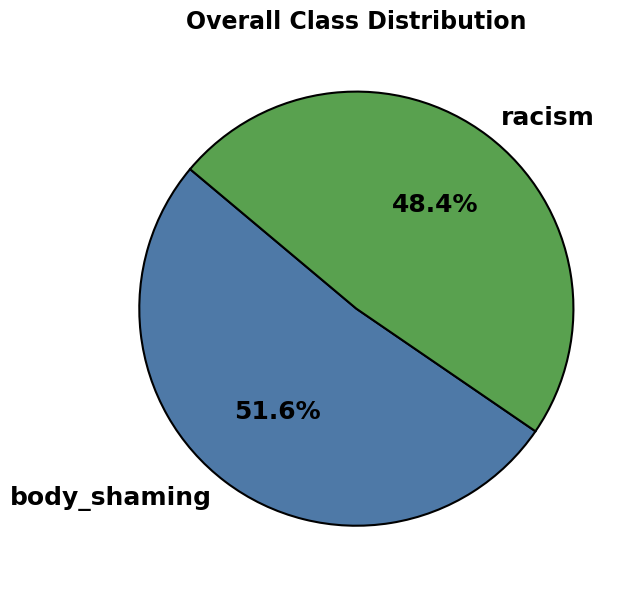

In [ ]:
import matplotlib.pyplot as plt

# Get class counts
counts = df['label'].value_counts()

colors = ['#4E79A7', '#59A14F', '#E15759', '#B07AA1', '#76B7B2']
colors = colors[:len(counts)]


plt.figure(figsize=(8,6))  # Bigger for clarity

# Plot pie chart
wedges, texts, autotexts = plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    textprops={'fontsize': 18, 'fontweight': 'bold', 'color': 'black'},
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5}
)

# Title
plt.title("Overall Class Distribution", fontsize=17, fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize encoder
le = LabelEncoder()

# Fit and transform
df['label_encoded'] = le.fit_transform(df['label'])

# Check
print(df[['label','label_encoded']].head())
print(df['label_encoded'].value_counts())


          label  label_encoded
0  body_shaming              0
1  body_shaming              0
2        racism              1
3  body_shaming              0
4        racism              1
label_encoded
0    812
1    763
Name: count, dtype: int64


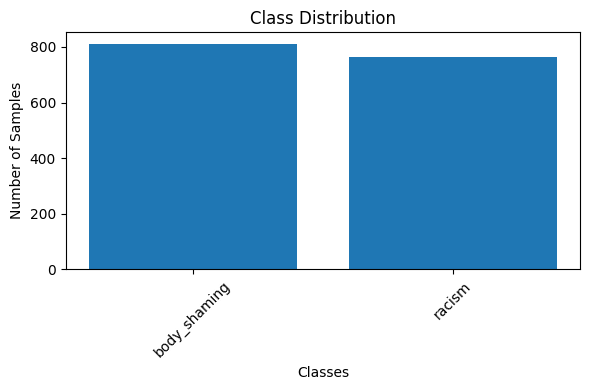

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# Count class frequency
counts = df['label_encoded'].value_counts().sort_index()

# Get class names (optional but better)
class_names = le.inverse_transform(counts.index)

# Plot
plt.figure(figsize=(6,4))
plt.bar(class_names, counts.values)

plt.xlabel("Classes")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df['label']
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['label']
)
print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
y_train = train_df['label'].values
y_val = val_df['label'].values
y_test = test_df['label'].values


Train: 1102 Val: 236 Test: 237


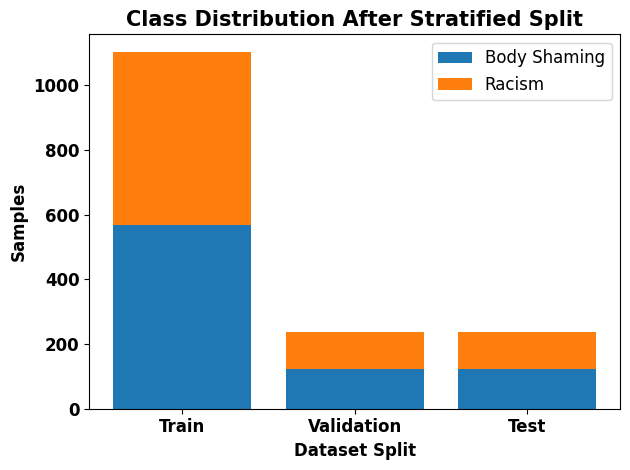

In [ ]:
def plot_split_distribution(train_df, val_df, test_df):
    splits = ['Train', 'Validation', 'Test']

    body_counts = [
        sum(train_df['label'] == 'body_shaming'),
        sum(val_df['label'] == 'body_shaming'),
        sum(test_df['label'] == 'body_shaming')
    ]

    racism_counts = [
        sum(train_df['label'] == 'racism'),
        sum(val_df['label'] == 'racism'),
        sum(test_df['label'] == 'racism')
    ]

    x = range(len(splits))

    plt.figure()
    plt.bar(x, body_counts, label='Body Shaming')
    plt.bar(x, racism_counts, bottom=body_counts, label='Racism')

    # Bold & larger fonts
    plt.xticks(x, splits, fontsize=12, fontweight='bold')
    plt.xlabel("Dataset Split", fontsize=12, fontweight='bold')
    plt.ylabel("Samples", fontsize=12, fontweight='bold')
    plt.title("Class Distribution After Stratified Split", fontsize=15, fontweight='bold')

    plt.yticks(fontsize=12, fontweight='bold')
    plt.legend(fontsize=12)

    plt.tight_layout()
    plt.show()

plot_split_distribution(train_df, val_df, test_df)


In [ ]:
le = LabelEncoder()
le.fit(df['label'].values)
print("Label classes (str -> int):", dict(zip(le.classes_, le.transform(le.classes_))))

y_train = le.transform(train_df['label'].values)
y_val   = le.transform(val_df['label'].values)
y_test  = le.transform(test_df['label'].values)


Label classes (str -> int): {'body_shaming': np.int64(0), 'racism': np.int64(1)}


In [ ]:
tfidf = TfidfVectorizer(
    analyzer='char',
    ngram_range=(1,2),
    min_df=3,
    max_features=50000
)

X_train_tfidf = tfidf.fit_transform(train_df['clean_text'])
X_val_tfidf   = tfidf.transform(val_df['clean_text'])
X_test_tfidf  = tfidf.transform(test_df['clean_text'])
print("Original train label distribution:", Counter(y_train))

Original train label distribution: Counter({np.int64(0): 568, np.int64(1): 534})


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


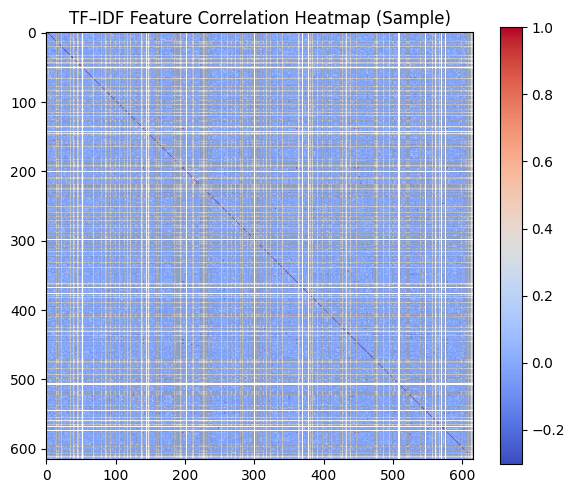

In [ ]:
import numpy as np

# Convert small subset to dense for visualization
X_dense = X_train_tfidf[:200].toarray()

corr = np.corrcoef(X_dense.T)

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()
plt.title("TF–IDF Feature Correlation Heatmap (Sample)")
plt.tight_layout()
plt.show()


In [ ]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_tfidf, y_train)
print("After SMOTE:", Counter(y_train_sm))

After SMOTE: Counter({np.int64(0): 568, np.int64(1): 568})


In [ ]:
# ============================================================
# 5-FOLD STRATIFIED CROSS-VALIDATION FOR ALL MODELS
# Addresses Reviewer #4: "lacks statistical significance
# testing or cross-validation"
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import numpy as np

# Use the full dataset text and labels
X_all = df['clean_text'].values
y_all = le.transform(df['label'].values)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---- Classical ML pipelines with SMOTE inside CV ----
# IMPORTANT: SMOTE must be INSIDE the CV loop to prevent data leakage

lr_pipe = ImbPipeline([
    ('tfidf', TfidfVectorizer(analyzer='char', ngram_range=(1,2),
                               min_df=3, max_features=50000)),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced',
                                random_state=42))
])

svm_pipe = ImbPipeline([
    ('tfidf', TfidfVectorizer(analyzer='char', ngram_range=(1,2),
                               min_df=3, max_features=50000)),
    ('smote', SMOTE(random_state=42)),
    ('clf', SVC(kernel='linear', probability=True, random_state=42))
])

rf_pipe = ImbPipeline([
    ('tfidf', TfidfVectorizer(analyzer='char', ngram_range=(1,2),
                               min_df=3, max_features=50000)),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(n_estimators=300, random_state=42,
                                    n_jobs=-1))
])

classical_models = {
    'Logistic Regression': lr_pipe,
    'SVM (Linear)':        svm_pipe,
    'Random Forest':       rf_pipe
}

cv_results = {}

print("Running 5-Fold Cross-Validation for Classical Models...")
print("="*60)

for name, pipe in classical_models.items():
    scores = cross_val_score(pipe, X_all, y_all,
                             cv=skf, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name}:")
    print(f"  Fold Scores : {[round(s, 4) for s in scores]}")
    print(f"  Mean Acc    : {scores.mean():.4f}")
    print(f"  Std Dev     : {scores.std():.4f}")
    print()

Running 5-Fold Cross-Validation for Classical Models...
Logistic Regression:
  Fold Scores : [np.float64(0.9302), np.float64(0.9492), np.float64(0.9206), np.float64(0.9302), np.float64(0.9143)]
  Mean Acc    : 0.9289
  Std Dev     : 0.0118

SVM (Linear):
  Fold Scores : [np.float64(0.9397), np.float64(0.9556), np.float64(0.9302), np.float64(0.9492), np.float64(0.9302)]
  Mean Acc    : 0.9410
  Std Dev     : 0.0102

Random Forest:
  Fold Scores : [np.float64(0.9302), np.float64(0.9619), np.float64(0.9365), np.float64(0.9429), np.float64(0.9302)]
  Mean Acc    : 0.9403
  Std Dev     : 0.0118



In [ ]:
!wget -q https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansBengali/NotoSansBengali-Regular.ttf


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/content/NotoSansBengali-Regular.ttf"
bangla_font = fm.FontProperties(fname=font_path)


In [ ]:
def eval_test_only(name, model, X_test, y_test, target_names):
    target_names = le.classes_
    preds = model.predict(X_test)
    print(f"\n=== {name} (Test Results) ===")
    print("Test Accuracy:", accuracy_score(y_test, preds))
    print(classification_report(y_test, preds, target_names=target_names, digits=4))
    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))

In [ ]:
#Logistic Regression
lr = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)

lr.fit(X_train_sm, y_train_sm)
target_names = le.classes_
eval_test_only("LogisticRegression", lr, X_test_tfidf, y_test, target_names)
joblib.dump({'model': lr, 'tfidf': tfidf, 'label_encoder': le}, '/content/logistic_tfidf.joblib')


=== LogisticRegression (Test Results) ===
Test Accuracy: 0.9324894514767933
              precision    recall  f1-score   support

body_shaming     0.9274    0.9426    0.9350       122
      racism     0.9381    0.9217    0.9298       115

    accuracy                         0.9325       237
   macro avg     0.9327    0.9322    0.9324       237
weighted avg     0.9326    0.9325    0.9325       237

Confusion Matrix:
 [[115   7]
 [  9 106]]


['/content/logistic_tfidf.joblib']

In [ ]:
# SVM (linear)
svc = SVC(kernel='linear', probability=True, random_state=42)
svc.fit(X_train_sm, y_train_sm)
target_names = le.classes_
eval_test_only("SVM (linear)", svc, X_test_tfidf, y_test, target_names)
joblib.dump({'model': svc, 'tfidf': tfidf, 'label_encoder': le}, '/content/svm_tfidf.joblib')



=== SVM (linear) (Test Results) ===
Test Accuracy: 0.9535864978902954
              precision    recall  f1-score   support

body_shaming     0.9587    0.9508    0.9547       122
      racism     0.9483    0.9565    0.9524       115

    accuracy                         0.9536       237
   macro avg     0.9535    0.9537    0.9536       237
weighted avg     0.9536    0.9536    0.9536       237

Confusion Matrix:
 [[116   6]
 [  5 110]]


['/content/svm_tfidf.joblib']

In [ ]:
# Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)
target_names = le.classes_
eval_test_only("RandomForest", rf, X_test_tfidf, y_test, target_names)
joblib.dump({'model': rf, 'tfidf': tfidf, 'label_encoder': le}, '/content/rf_tfidf.joblib')



=== RandomForest (Test Results) ===
Test Accuracy: 0.9409282700421941
              precision    recall  f1-score   support

body_shaming     0.9355    0.9508    0.9431       122
      racism     0.9469    0.9304    0.9386       115

    accuracy                         0.9409       237
   macro avg     0.9412    0.9406    0.9408       237
weighted avg     0.9410    0.9409    0.9409       237

Confusion Matrix:
 [[116   6]
 [  8 107]]


['/content/rf_tfidf.joblib']

In [ ]:
# Load pre-trained models and components
lr_data = joblib.load('/content/logistic_tfidf.joblib')
svc_data = joblib.load('/content/svm_tfidf.joblib')
rf_data = joblib.load('/content/rf_tfidf.joblib')

lr_model = lr_data['model']
svc_model = svc_data['model']
rf_model = rf_data['model']

class_names = list(le.classes_)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np
import os

PLOTS_DIR = '/content/lstm_plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

def plot_confusion_matrix(y_true, y_pred, class_names, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(9, 7))
    # ---- Plot matrix ----
    im = plt.imshow(cm_norm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title, fontsize=20, fontweight='bold', pad=16)

    # ---- Colorbar ----
    cbar = plt.colorbar(im, fraction=0.05, pad=0.04)
    cbar.ax.tick_params(labelsize=16, width=1.5)
    cbar.set_label("Normalized Value", fontsize=18, fontweight='bold', labelpad=12)

    # ---- Axis ticks ----
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, fontsize=18, fontweight='bold')
    plt.yticks(tick_marks, class_names, fontsize=18, fontweight='bold')

    # ---- Cell annotations ----
    fmt = '.2f'
    thresh = cm_norm.max() / 2.0
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            plt.text(
                j, i,
                format(cm_norm[i, j], fmt),
                ha="center",
                va="center",
                fontsize=20,  # Increased font for clarity
                fontweight='bold',
                color="white" if cm_norm[i, j] > thresh else "black"
            )

    # ---- Axis labels ----
    plt.ylabel("True Label", fontsize=18, fontweight='bold')
    plt.xlabel("Predicted Label", fontsize=18, fontweight='bold')

    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, filename), dpi=400)
    print(f"Saved: {os.path.join(PLOTS_DIR, filename)}")
    plt.show()


Saved: /content/lstm_plots/confusion_matrix_lr.png


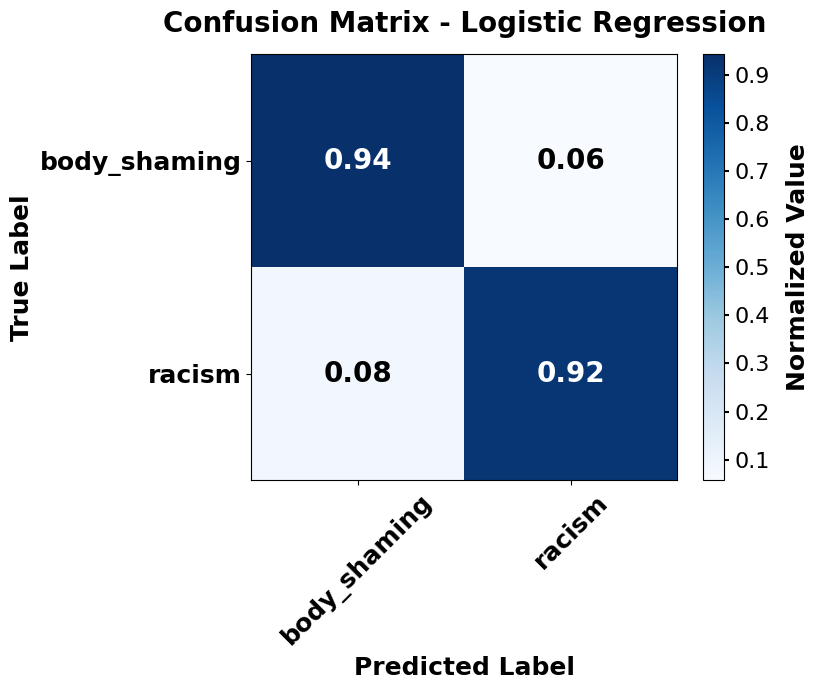

In [ ]:
# Logistic Regression Confusion Matrix
lr_preds = lr_model.predict(X_test_tfidf)
plot_confusion_matrix(y_test, lr_preds, class_names, 'Confusion Matrix - Logistic Regression', 'confusion_matrix_lr.png')


Saved: /content/lstm_plots/confusion_matrix_svm.png


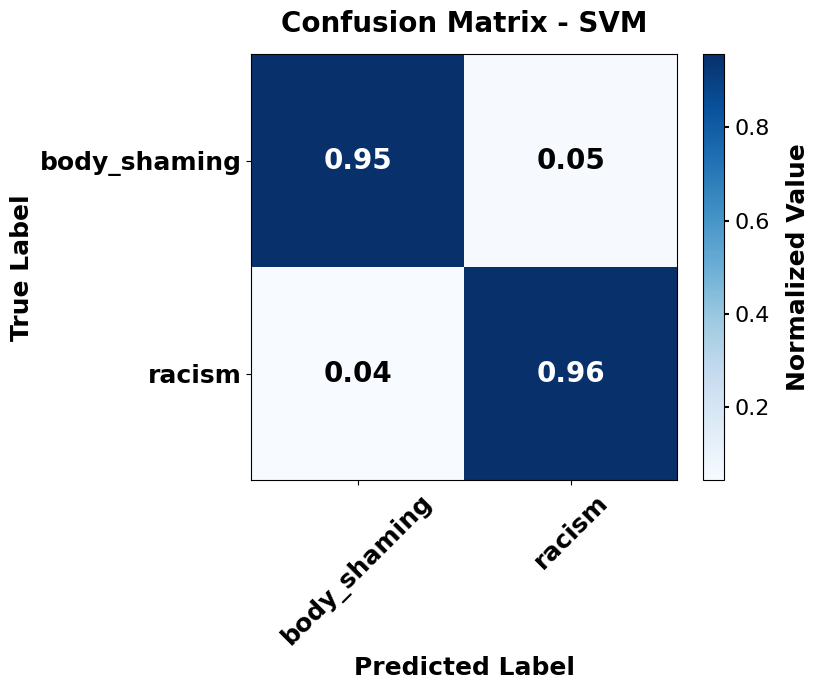

In [ ]:
# SVM Confusion Matrix
svc_preds = svc_model.predict(X_test_tfidf)
plot_confusion_matrix(y_test, svc_preds, class_names, 'Confusion Matrix - SVM', 'confusion_matrix_svm.png')


Saved: /content/lstm_plots/confusion_matrix_rf.png


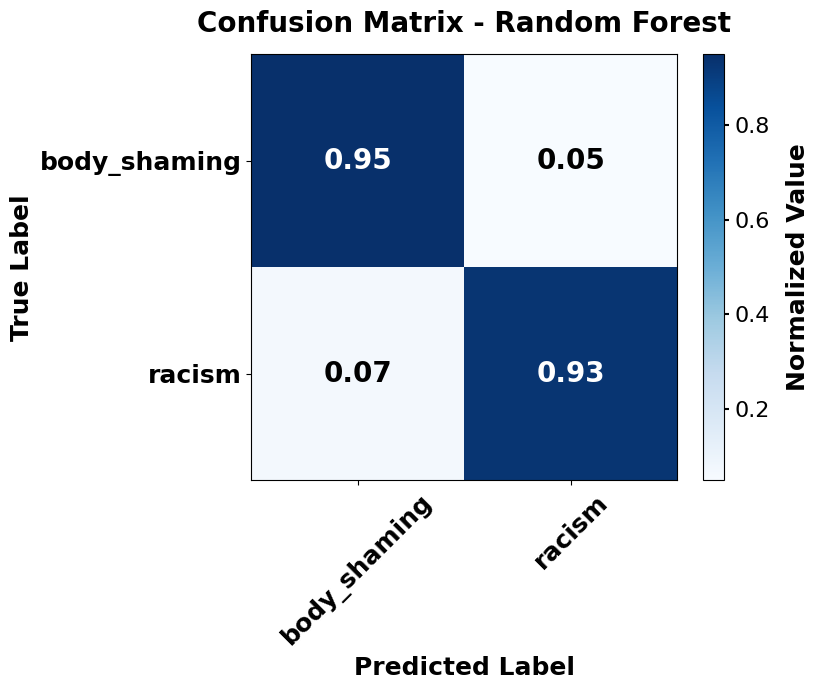

In [ ]:
# Random Forest Confusion Matrix
rf_preds = rf_model.predict(X_test_tfidf)
plot_confusion_matrix(y_test, rf_preds, class_names, 'Confusion Matrix - Random Forest', 'confusion_matrix_rf.png')

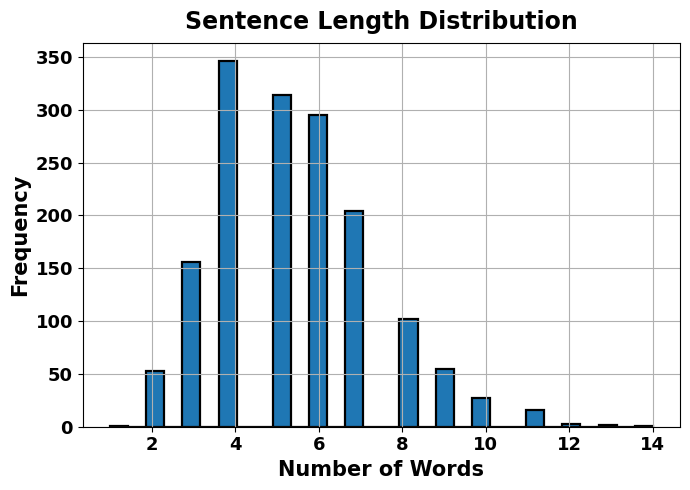

count    1575.000000
mean        5.434921
std         1.899823
min         1.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        14.000000
Name: sentence_length, dtype: float64


In [ ]:
df['sentence_length'] = df['clean_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(7, 5))

plt.hist(
    df['sentence_length'],
    bins=30,
    edgecolor='black',
    linewidth=1.6
)

# Bold axis labels
plt.xlabel("Number of Words", fontsize=15, fontweight='bold')
plt.ylabel("Frequency", fontsize=15, fontweight='bold')

# Bold title
plt.title(
    "Sentence Length Distribution",
    fontsize=17,
    fontweight='bold',
    pad=10
)

# Bold ticks
plt.xticks(fontsize=13, fontweight='bold')
plt.yticks(fontsize=13, fontweight='bold')

# Normal grid (NOT bold)
plt.grid(True)

plt.tight_layout()
plt.show()

print(df['sentence_length'].describe())


In [ ]:
MAX_WORDS = 30000
MAX_LEN   = 100
EMBED_DIM = 300
LR        = 1e-4
EPOCHS    = 15
BATCH     = 32


In [ ]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = callbacks.ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True
)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<unk>')
tokenizer.fit_on_texts(train_df['clean_text'])

X_train_seq = tokenizer.texts_to_sequences(train_df['clean_text'])
X_val_seq   = tokenizer.texts_to_sequences(val_df['clean_text'])
X_test_seq  = tokenizer.texts_to_sequences(test_df['clean_text'])

X_train_seq = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_seq   = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq  = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

y_train_seq = le.transform(train_df['label'].values)
y_val_seq   = le.transform(val_df['label'].values)
y_test_seq  = le.transform(test_df['label'].values)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_seq),
    y=y_train_seq
)
class_weights = dict(enumerate(class_weights))

**BiLSTM Model**

In [ ]:
model_bilstm = models.Sequential([
    layers.Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBED_DIM,
        input_length=MAX_LEN,
        mask_zero=True
    ),

    layers.SpatialDropout1D(0.35),

    layers.Bidirectional(
        layers.LSTM(
            32,                     # HALF units
            return_sequences=False,
            dropout=0.3,
            recurrent_dropout=0.3,
            kernel_regularizer=regularizers.l2(1e-4)
        )
    ),

    layers.Dense(
        32,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)
    ),

    layers.Dropout(0.4),

    layers.Dense(1, activation='sigmoid')
])

model_bilstm.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(LR),
    metrics=['accuracy']
)

model_bilstm.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_bilstm = model_bilstm.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=EPOCHS,
    batch_size=BATCH,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint],
    verbose=1
)


Epoch 1/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 802ms/step - accuracy: 0.5095 - loss: 0.7328

35/35 ━━━━━━━━━━━━━━━━━━━━ 59s 878ms/step - accuracy: 0.5227 - loss: 0.7314 - val_accuracy: 0.6907 - val_loss: 0.7277
Epoch 2/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 800ms/step - accuracy: 0.5930 - loss: 0.7267

35/35 ━━━━━━━━━━━━━━━━━━━━ 29s 843ms/step - accuracy: 0.6134 - loss: 0.7253 - val_accuracy: 0.7966 - val_loss: 0.7219
Epoch 3/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 811ms/step - accuracy: 0.6773 - loss: 0.7207

35/35 ━━━━━━━━━━━━━━━━━━━━ 30s 855ms/step - accuracy: 0.7042 - loss: 0.7176 - val_accuracy: 0.8220 - val_loss: 0.7130
Epoch 4/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 898ms/step - accuracy: 0.7969 - loss: 0.7063

35/35 ━━━━━━━━━━━━━━━━━━━━ 33s 949ms/step - accuracy: 0.8058 - loss: 0.7055 - val_accuracy: 0.8602 - val_loss: 0.6998
Epoch 5/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 812ms/step - accuracy: 0.8270 - loss: 0.6928

...

35/35 ━━━━━━━━━━━━━━━━━━━━ 32s 895ms/step - accuracy: 0.9655 - loss: 0.3120 - val_accuracy: 0.9280 - val_loss: 0.3236
Epoch 12/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 860ms/step - accuracy: 0.9687 - loss: 0.2657

35/35 ━━━━━━━━━━━━━━━━━━━━ 41s 924ms/step - accuracy: 0.9701 - loss: 0.2461 - val_accuracy: 0.9280 - val_loss: 0.2713
Epoch 13/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 810ms/step - accuracy: 0.9823 - loss: 0.1928

35/35 ━━━━━━━━━━━━━━━━━━━━ 39s 853ms/step - accuracy: 0.9773 - loss: 0.1893 - val_accuracy: 0.9322 - val_loss: 0.2349
Epoch 14/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 815ms/step - accuracy: 0.9864 - loss: 0.1650

35/35 ━━━━━━━━━━━━━━━━━━━━ 31s 874ms/step - accuracy: 0.9837 - loss: 0.1561 - val_accuracy: 0.9407 - val_loss: 0.2097
Epoch 15/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 823ms/step - accuracy: 0.9803 - loss: 0.1406

35/35 ━━━━━━━━━━━━━━━━━━━━ 41s 876ms/step - accuracy: 0.9855 - loss: 0.1336 - val_accuracy: 0.9407 - val_loss: 0.1921


In [ ]:
# Evaluate
val_preds = (model_bilstm.predict(X_val_seq) > 0.5).astype(int).flatten()

test_preds = (model_bilstm.predict(X_test_seq) > 0.5).astype(int).flatten()
print("BiLSTM Validation Accuracy:", accuracy_score(y_val_seq, val_preds))
print("BiLSTM Test Accuracy:", accuracy_score(y_test_seq, test_preds))
print("Classification Report (Test):\n", classification_report(y_test_seq, test_preds, digits=4))
print("Confusion Matrix (Test):\n", confusion_matrix(y_test_seq, test_preds))

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 328ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step
BiLSTM Validation Accuracy: 0.940677966101695
BiLSTM Test Accuracy: 0.9535864978902954
Classification Report (Test):
               precision    recall  f1-score   support

           0     0.9302    0.9836    0.9562       122
           1     0.9815    0.9217    0.9507       115

    accuracy                         0.9536       237
   macro avg     0.9559    0.9527    0.9534       237
weighted avg     0.9551    0.9536    0.9535       237

Confusion Matrix (Test):
 [[120   2]
 [  9 106]]


In [ ]:

def predict_texts(texts, model, tokenizer, label_encoder, max_len=100, threshold=0.5):
    # convert texts -> sequences -> padded
    seqs = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(seqs, maxlen=max_len, padding='post', truncating='post')
    probs = model.predict(padded, batch_size=32).flatten()  # sigmoid outputs
    results = []
    for txt, p in zip(texts, probs):
        pred_int = int(p > threshold)
        pred_label = label_encoder.inverse_transform([pred_int])[0]
        results.append({'text': txt, 'probability_racism': float(p) if label_encoder.classes_[1]=='racism' else float(1-p),
                        'pred_int': pred_int, 'pred_label': pred_label})
    return results

unseen = [
    "তোর দাঁত গুলো উচা কেন",
    "কালো মানুষ দেখলেই মেজাজ খারাপ হয়",
    "তুই তো হুবুহু বানরের মতো দেখতে",
    "তোর রান দুটো এতো মোটা কেন?"
]

res = predict_texts(unseen, model_bilstm, tokenizer, le, max_len=100, threshold=0.5)
for r in res:
    print("TEXT:", r['text'])
    print("PRED:", r['pred_label'], "| Prob (racism):", round(r['probability_racism'], 4))
    print("----")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
TEXT: তোর দাঁত গুলো উচা কেন
PRED: body_shaming | Prob (racism): 0.1071
----
TEXT: কালো মানুষ দেখলেই মেজাজ খারাপ হয়
PRED: racism | Prob (racism): 0.9929
----
TEXT: তুই তো হুবুহু বানরের মতো দেখতে
PRED: body_shaming | Prob (racism): 0.0603
----
TEXT: তোর রান দুটো এতো মোটা কেন?
PRED: body_shaming | Prob (racism): 0.0089
----


In [ ]:
ARTIFACT_PATH = '/content/lstm_tokenizer_le.joblib'
MODEL_PATH = '/content/final_lstm_model.h5'
PRED_CSV = '/content/lstm_test_predictions.csv'
PLOTS_DIR = '/content/lstm_plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

# Assign the BiLSTM model to a generic 'model' variable to satisfy the assert condition
model = model_bilstm

assert 'model' in globals(), "Model not found in memory — load it (uncomment load lines)."
assert 'tokenizer' in globals(), "Tokenizer not found — load it or re-run tokenizer.fit..."
assert 'le' in globals(), "LabelEncoder not found — load it or recreate it."

# Ensure test data exists
if 'X_test_seq' not in globals():
    X_test_seq = tokenizer.texts_to_sequences(test_df['clean_text'])
    X_test_seq = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')
if 'y_test_seq' not in globals():
    y_test_seq = le.transform(test_df['label'].values)

Saved: /content/lstm_plots/loss_curve.png


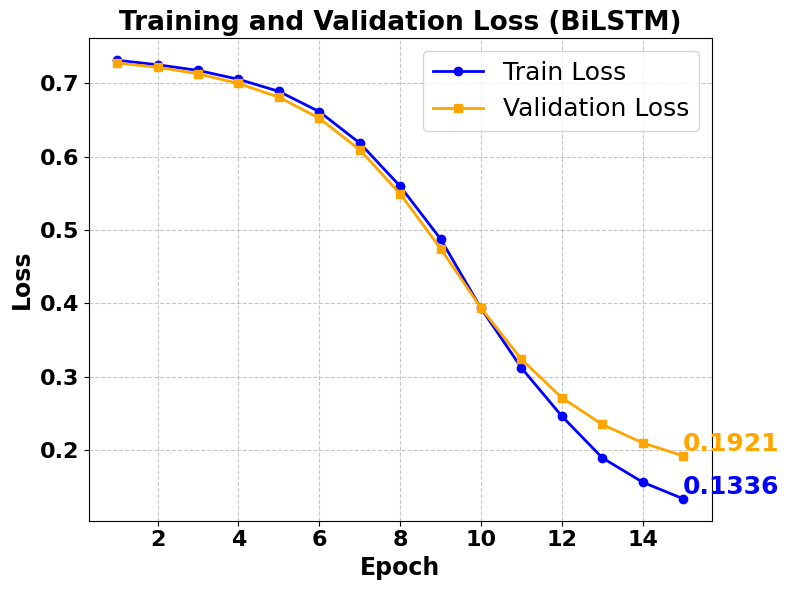

In [ ]:
import matplotlib.pyplot as plt
import os

# CHANGED: Check for 'history_bilstm', not 'history'
if 'history_bilstm' in globals():
    plt.figure(figsize=(8, 6))
    epochs = range(1, len(history_bilstm.history['loss']) + 1)

    # Plot training loss
    plt.plot(epochs, history_bilstm.history['loss'], marker='o', color='blue', linewidth=2, label='Train Loss')

    # Plot validation loss if available
    if 'val_loss' in history_bilstm.history:
        plt.plot(epochs, history_bilstm.history['val_loss'], marker='s', color='orange', linewidth=2, label='Validation Loss')

    plt.title('Training and Validation Loss (BiLSTM)', fontsize=19, fontweight='bold')
    plt.xlabel('Epoch', fontsize=17, fontweight='bold')
    plt.ylabel('Loss', fontsize=17, fontweight='bold')
    plt.xticks(fontsize=16, fontweight='bold')
    plt.yticks(fontsize=16, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Highlight final scores
    final_train_loss = history_bilstm.history['loss'][-1]
    plt.text(epochs[-1], final_train_loss, f'{final_train_loss:.4f}',
             fontsize=18, fontweight='bold', color='blue',
              ha='left', va='bottom')

    if 'val_loss' in history_bilstm.history:
        final_val_loss = history_bilstm.history['val_loss'][-1]
        plt.text(epochs[-1], final_val_loss, f'{final_val_loss:.4f}',
                 fontsize=18, fontweight='bold', color='orange',
                 ha='left', va='bottom')

    plt.legend(fontsize=18, loc='upper right', frameon=True)
    plt.tight_layout()

    loss_path = os.path.join(PLOTS_DIR, 'loss_curve.png')
    plt.savefig(loss_path, dpi=500)
    print("Saved:", loss_path)
    plt.show()
else:
    print("Error: 'history_bilstm' not found. Make sure you ran the training cell.")

Saved: /content/lstm_plots/accuracy_curve.png


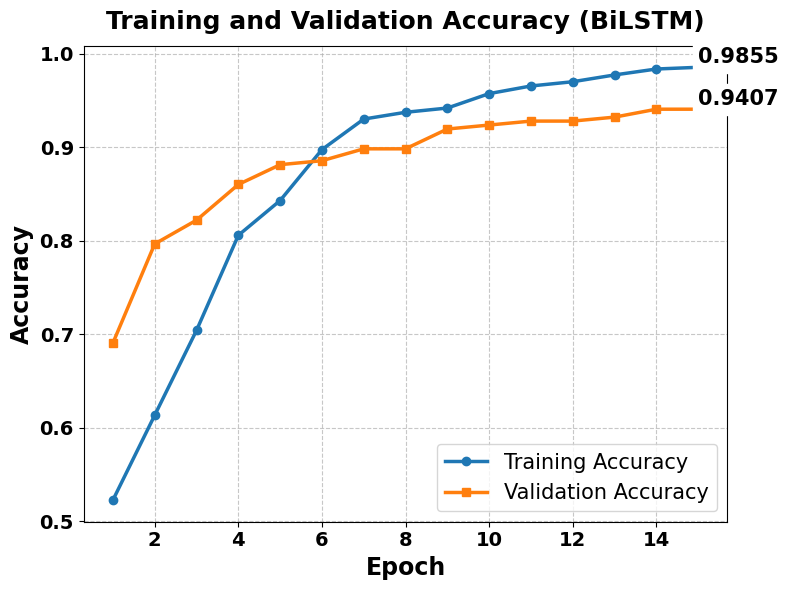

In [ ]:
import matplotlib.pyplot as plt
import os

# CHANGED: Check for 'history_bilstm', not 'history'
if 'history_bilstm' in globals() and 'accuracy' in history_bilstm.history:

    plt.figure(figsize=(8, 6))
    epochs = range(1, len(history_bilstm.history['accuracy']) + 1)

    # Training accuracy
    plt.plot(epochs, history_bilstm.history['accuracy'], marker='o', linewidth=2.5, label='Training Accuracy')

    # Validation accuracy
    if 'val_accuracy' in history_bilstm.history:
        plt.plot(epochs, history_bilstm.history['val_accuracy'], marker='s', linewidth=2.5, label='Validation Accuracy')

    plt.title("Training and Validation Accuracy (BiLSTM)", fontsize=18, fontweight='bold', pad=12)
    plt.xlabel("Epoch", fontsize=17, fontweight='bold')
    plt.ylabel("Accuracy", fontsize=17, fontweight='bold')
    plt.xticks(fontsize=14, fontweight='bold')
    plt.yticks(fontsize=14, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Highlight final values
    final_train_acc = history_bilstm.history['accuracy'][-1]
    plt.text(epochs[-1], final_train_acc, f'{final_train_acc:.4f}',
             fontsize=15, fontweight='bold', backgroundcolor='white', ha='left', va='bottom')

    if 'val_accuracy' in history_bilstm.history:
        final_val_acc = history_bilstm.history['val_accuracy'][-1]
        plt.text(epochs[-1], final_val_acc, f'{final_val_acc:.4f}',
                 fontsize=15, fontweight='bold', backgroundcolor='white', ha='left', va='bottom')

    plt.legend(fontsize=15, loc='lower right', frameon=True)
    plt.tight_layout()

    acc_path = os.path.join(PLOTS_DIR, "accuracy_curve.png")
    plt.savefig(acc_path, dpi=400, bbox_inches='tight')
    print("Saved:", acc_path)
    plt.show()

else:
    print("No 'history_bilstm' object found — skipping accuracy plot.")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step
Label encoder classes: ['body_shaming', 'racism']
Saved test predictions to: /content/lstm_test_predictions.csv
Saved: /content/lstm_plots/confusion_matrix_normalized.png


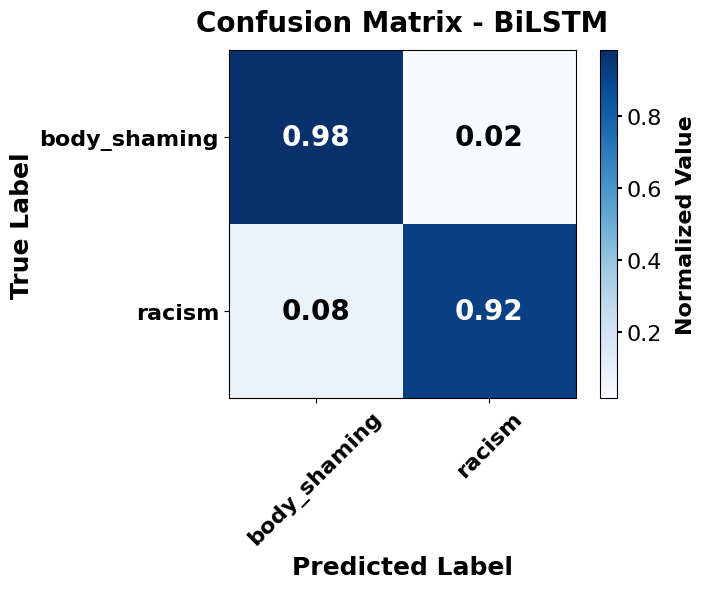

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import confusion_matrix

# Compute predictions
probs = model_bilstm.predict(X_test_seq, batch_size=64).flatten()
preds_int = (probs > 0.5).astype(int)

class_names = list(le.classes_)
print("Label encoder classes:", class_names)

# Save test predictions to CSV
df_preds = pd.DataFrame({
    'text': test_df['clean_text'].values,
    'true_label_int': y_test_seq,
    'true_label_str': le.inverse_transform(y_test_seq),
    'pred_int': preds_int,
    'pred_str': le.inverse_transform(preds_int),
    'prob_positive': probs
})
df_preds.to_csv(PRED_CSV, index=False)
print("Saved test predictions to:", PRED_CSV)

# Confusion matrix
cm = confusion_matrix(y_test_seq, preds_int)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# ---- Updated figure size for readability ----
plt.figure(figsize=(8, 6))  # Slightly larger for bigger fonts

# Show normalized confusion matrix
im = plt.imshow(cm_norm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix - BiLSTM', fontsize=20, fontweight='bold', pad=14)
plt.xlabel('Predicted Label', fontsize=18, fontweight='bold')
plt.ylabel('True Label', fontsize=18, fontweight='bold')

# Tick labels
plt.xticks(np.arange(len(class_names)), class_names, fontsize=16, fontweight='bold', rotation=45)
plt.yticks(np.arange(len(class_names)), class_names, fontsize=16, fontweight='bold')

# Colorbar
cbar = plt.colorbar(im, fraction=0.05, pad=0.04)
cbar.ax.tick_params(labelsize=16, width=1.5)
cbar.set_label("Normalized Value", fontsize=16, fontweight='bold', labelpad=10)

# Annotate cells with normalized values (larger font)
fmt = '.2f'
thresh = cm_norm.max() / 2.0
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(
            j, i,
            format(cm_norm[i, j], fmt),
            ha='center',
            va='center',
            fontsize=20,  # Increased for clarity
            fontweight='bold',
            color='white' if cm_norm[i, j] > thresh else 'black'
        )

plt.tight_layout()

# Save figure
cm_norm_path = os.path.join(PLOTS_DIR, 'confusion_matrix_normalized.png')
plt.savefig(cm_norm_path, dpi=500)  # High resolution
print("Saved:", cm_norm_path)
plt.show()


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step
Saved: /content/lstm_plots/roc_curve_bilstm.png


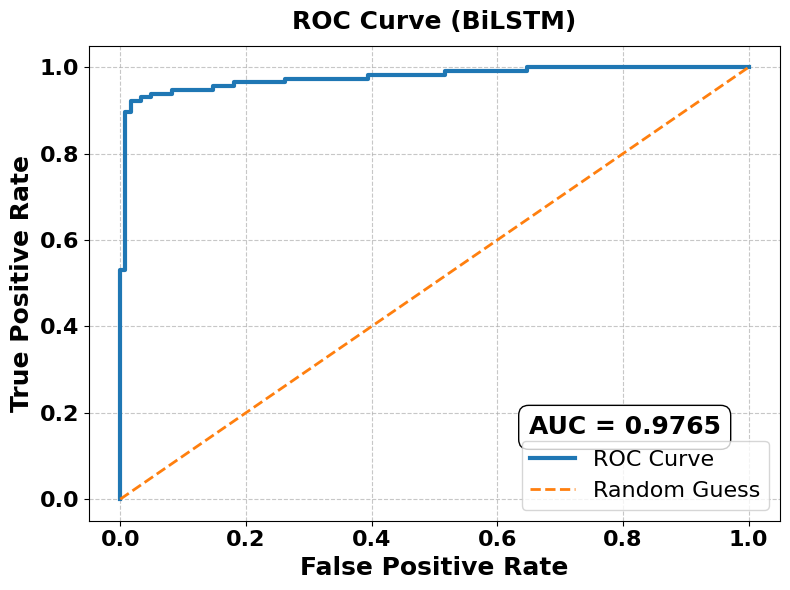

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import roc_curve, auc

# -----------------------------
# ROC Curve (LSTM)
# -----------------------------
probs = model_bilstm.predict(X_test_seq, batch_size=64).flatten()

fpr, tpr, _ = roc_curve(y_test_seq, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label='ROC Curve'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=2,
    label='Random Guess'
)

# Title & labels
plt.title(
    "ROC Curve (BiLSTM)",
    fontsize=18,
    fontweight='bold',
    pad=12
)
plt.xlabel("False Positive Rate", fontsize=18, fontweight='bold')
plt.ylabel("True Positive Rate", fontsize=18, fontweight='bold')

# Ticks
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')

# Grid
plt.grid(True, linestyle='--', alpha=0.7)

# -----------------------------
# AUC box (highlighted)
# -----------------------------
plt.text(
    0.65, 0.15,
    f"AUC = {roc_auc:.4f}",
    fontsize=18,
    fontweight='bold',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.4')
)

# Legend
plt.legend(fontsize=16, loc='lower right', frameon=True)

plt.tight_layout()

# Save
roc_path = os.path.join(PLOTS_DIR, "roc_curve_bilstm.png")
plt.savefig(roc_path, dpi=400, bbox_inches='tight')
print("Saved:", roc_path)

plt.show()


**LSTM MODEL**

In [ ]:
model_lstm = models.Sequential([
    layers.Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBED_DIM,
        input_length=MAX_LEN,
        mask_zero=True
    ),

    layers.SpatialDropout1D(0.3),

    layers.LSTM(
        64,
        return_sequences=False,
        dropout=0.3,
        recurrent_dropout=0.3,
        kernel_regularizer=regularizers.l2(1e-4)
    ),

    layers.Dense(
        32,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)
    ),

    layers.Dropout(0.4),

    layers.Dense(1, activation='sigmoid')
])

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(LR),
    metrics=['accuracy']
)

model_lstm.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_lstm = model_lstm.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=EPOCHS,
    batch_size=BATCH,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint],
    verbose=1
)


Epoch 1/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 23s 480ms/step - accuracy: 0.5472 - loss: 0.7230 - val_accuracy: 0.6271 - val_loss: 0.7210
Epoch 2/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 16s 460ms/step - accuracy: 0.6062 - loss: 0.7176 - val_accuracy: 0.6907 - val_loss: 0.7156
Epoch 3/15
31/35 ━━━━━━━━━━━━━━━━━━━━ 1s 449ms/step - accuracy: 0.6664 - loss: 0.7129

In [ ]:
val_preds = (model_lstm.predict(X_val_seq) > 0.5).astype(int).flatten()
test_preds = (model_lstm.predict(X_test_seq) > 0.5).astype(int).flatten()

print("LSTM Validation Accuracy:", accuracy_score(y_val_seq, val_preds))
print("LSTM Test Accuracy:", accuracy_score(y_test_seq, test_preds))

print(
    "Classification Report (Test):\n",
    classification_report(y_test_seq, test_preds, digits=4)
)

print(
    "Confusion Matrix (Test):\n",
    confusion_matrix(y_test_seq, test_preds)
)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import confusion_matrix

# -----------------------------
# Predictions (LSTM)
# -----------------------------
probs = model_lstm.predict(X_test_seq, batch_size=64).flatten()
preds_int = (probs > 0.5).astype(int)

class_names = list(le.classes_)
print("Label encoder classes:", class_names)

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test_seq, preds_int)

# Row-wise normalization
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8, 6))

im = plt.imshow(cm_norm, interpolation='nearest', cmap=plt.cm.Blues)

plt.title(
    "Confusion Matrix - LSTM",
    fontsize=20,
    fontweight='bold',
    pad=15
)

plt.xlabel("Predicted Label", fontsize=18, fontweight='bold')
plt.ylabel("True Label", fontsize=18, fontweight='bold')

# Tick labels
plt.xticks(
    np.arange(len(class_names)),
    class_names,
    fontsize=16,
    fontweight='bold',
    rotation=45
)
plt.yticks(
    np.arange(len(class_names)),
    class_names,
    fontsize=16,
    fontweight='bold'
)

# Colorbar
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=16, width=1.5)
cbar.set_label(
    "Normalized Value",
    fontsize=16,
    fontweight='bold',
    labelpad=12
)

# -----------------------------
# Annotate values
# -----------------------------
fmt = ".2f"
threshold = cm_norm.max() / 2.0

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(
            j, i,
            format(cm_norm[i, j], fmt),
            ha="center",
            va="center",
            fontsize=20,
            fontweight="bold",
            color="white" if cm_norm[i, j] > threshold else "black"
        )

plt.tight_layout()

# -----------------------------
# Save figure
# -----------------------------
cm_path = os.path.join(PLOTS_DIR, "confusion_matrix_normalized_lstm.png")
plt.savefig(cm_path, dpi=500, bbox_inches="tight")
print("Saved confusion matrix to:", cm_path)

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import os

# CHANGED: Check for 'history_lstm', not 'history'
if 'history_lstm' in globals():
    plt.figure(figsize=(8, 6))
    epochs = range(1, len(history_lstm.history['loss']) + 1)

    # Plot training loss
    plt.plot(epochs, history_lstm.history['loss'], marker='o', color='blue', linewidth=2, label='Train Loss')

    # Plot validation loss if available
    if 'val_loss' in history_lstm.history:
        plt.plot(epochs, history_lstm.history['val_loss'], marker='s', color='orange', linewidth=2, label='Validation Loss')

    plt.title('Training and Validation Loss (LSTM)', fontsize=18, fontweight='bold')
    plt.xlabel('Epoch', fontsize=19, fontweight='bold')
    plt.ylabel('Loss', fontsize=19, fontweight='bold')
    plt.xticks(fontsize=16, fontweight='bold')
    plt.yticks(fontsize=16, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Highlight final scores
    final_train_loss = history_lstm.history['loss'][-1]
    plt.text(epochs[-1], final_train_loss, f'{final_train_loss:.4f}',
             fontsize=18, fontweight='bold', color='blue',
            ha='left', va='bottom')

    if 'val_loss' in history_lstm.history:
        final_val_loss = history_lstm.history['val_loss'][-1]
        plt.text(epochs[-1], final_val_loss, f'{final_val_loss:.4f}',
                 fontsize=18, fontweight='bold', color='orange',
                ha='left', va='bottom')

    plt.legend(fontsize=17, loc='upper right', frameon=True)
    plt.tight_layout()

    loss_path = os.path.join(PLOTS_DIR, 'loss_curve_lstm.png')
    plt.savefig(loss_path, dpi=500)
    print("Saved:", loss_path)
    plt.show()
else:
    print("Error: 'history_lstm' not found. Make sure you ran the training cell.")

In [ ]:
import matplotlib.pyplot as plt
import os

# -----------------------------
# Accuracy Curve (LSTM)
# -----------------------------
if 'history_lstm' in globals():

    plt.figure(figsize=(8, 6))
    epochs = range(1, len(history_lstm.history['accuracy']) + 1)

    # Training accuracy
    plt.plot(
        epochs,
        history_lstm.history['accuracy'],
        marker='o',
        linewidth=2.5,
        label='Training Accuracy'
    )

    # Validation accuracy
    if 'val_accuracy' in history_lstm.history:
        plt.plot(
            epochs,
            history_lstm.history['val_accuracy'],
            marker='s',
            linewidth=2.5,
            label='Validation Accuracy'
        )

    # Title & labels
    plt.title(
        "Training and Validation Accuracy (LSTM)",
        fontsize=18,
        fontweight='bold',
        pad=12
    )
    plt.xlabel("Epoch", fontsize=17, fontweight='bold')
    plt.ylabel("Accuracy", fontsize=17, fontweight='bold')

    # Ticks
    plt.xticks(fontsize=14, fontweight='bold')
    plt.yticks(fontsize=14, fontweight='bold')

    # Grid
    plt.grid(True, linestyle='--', alpha=0.7)

    # -----------------------------
    # Highlight final values
    # -----------------------------
    final_train_acc = history_lstm.history['accuracy'][-1]
    plt.text(
        epochs[-1],
        final_train_acc,
        f'{final_train_acc:.4f}',
        fontsize=15,
        fontweight='bold',
        backgroundcolor='white',
        ha='left',
        va='bottom'
    )

    if 'val_accuracy' in history_lstm.history:
        final_val_acc = history_lstm.history['val_accuracy'][-1]
        plt.text(
            epochs[-1],
            final_val_acc,
            f'{final_val_acc:.4f}',
            fontsize=15,
            fontweight='bold',
            backgroundcolor='white',
            ha='left',
            va='bottom'
        )

    # Legend
    plt.legend(fontsize=15, loc='lower right', frameon=True)

    plt.tight_layout()

    # Save
    acc_path = os.path.join(PLOTS_DIR, "accuracy_curve_lstm.png")
    plt.savefig(acc_path, dpi=500, bbox_inches='tight')
    print("Saved:", acc_path)

    plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import roc_curve, auc

# -----------------------------
# ROC Curve (LSTM)
# -----------------------------
probs = model_lstm.predict(X_test_seq, batch_size=64).flatten()

fpr, tpr, _ = roc_curve(y_test_seq, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label='ROC Curve'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=2,
    label='Random Guess'
)

# Title & labels
plt.title(
    "ROC Curve (LSTM)",
    fontsize=18,
    fontweight='bold',
    pad=12
)
plt.xlabel("False Positive Rate", fontsize=18, fontweight='bold')
plt.ylabel("True Positive Rate", fontsize=18, fontweight='bold')

# Ticks
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')

# Grid
plt.grid(True, linestyle='--', alpha=0.7)

# -----------------------------
# AUC box (highlighted)
# -----------------------------
plt.text(
    0.65, 0.15,
    f"AUC = {roc_auc:.4f}",
    fontsize=18,
    fontweight='bold',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.4')
)

# Legend
plt.legend(fontsize=16, loc='lower right', frameon=True)

plt.tight_layout()

# Save
roc_path = os.path.join(PLOTS_DIR, "roc_curve_lstm.png")
plt.savefig(roc_path, dpi=400, bbox_inches='tight')
print("Saved:", roc_path)

plt.show()


**CNN MODEL**

In [ ]:
model_cnn = tf.keras.Sequential([

    layers.Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBED_DIM,
        input_length=MAX_LEN
    ),

    layers.SpatialDropout1D(0.4),

    layers.Conv1D(
        filters=64,
        kernel_size=5,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)
    ),

    layers.GlobalMaxPooling1D(),

    layers.Dense(
        32,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)
    ),

    layers.Dropout(0.6),

    layers.Dense(1, activation='sigmoid')
])


In [ ]:
model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)


In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_cnn = model_cnn.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 134ms/step - accuracy: 0.5000 - loss: 0.7076 - val_accuracy: 0.5932 - val_loss: 0.7040
Epoch 2/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5064 - loss: 0.7050 - val_accuracy: 0.6314 - val_loss: 0.7007
Epoch 3/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5962 - loss: 0.6989 - val_accuracy: 0.6992 - val_loss: 0.6961
Epoch 4/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6044 - loss: 0.6934 - val_accuracy: 0.7331 - val_loss: 0.6898
Epoch 5/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6661 - loss: 0.6846 - val_accuracy: 0.7500 - val_loss: 0.6806
Epoch 6/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7160 - loss: 0.6699 - val_accuracy: 0.7839 - val_loss: 0.6645
Epoch 7/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7396 - loss: 0.6464 - val_accuracy: 0.8263 - val_loss: 0.6439
Epoch 8/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7713 - loss: 0.6218 - val_accuracy: 0.8814 - val_l

In [ ]:
# Evaluate
test_preds_cnn = (model_cnn.predict(X_test_seq) > 0.5).astype(int).flatten()

print("CNN Test Accuracy:", accuracy_score(y_test_seq, test_preds_cnn))
print(classification_report(y_test_seq, test_preds_cnn, target_names=le.classes_))
print(confusion_matrix(y_test_seq, test_preds_cnn))

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step
CNN Test Accuracy: 0.919831223628692
              precision    recall  f1-score   support

body_shaming       0.87      1.00      0.93       122
      racism       1.00      0.83      0.91       115

    accuracy                           0.92       237
   macro avg       0.93      0.92      0.92       237
weighted avg       0.93      0.92      0.92       237

[[122   0]
 [ 19  96]]


In [ ]:
for t in [
    "তুই দেখতে খুব মোটা",
    "কালো মানুষ ভালো না",
    "জাতের মানুষ খারাপ",
    "সে একজন কালা মানুষ"
]:
    print(predict_texts([t], model_cnn, tokenizer, le)[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
{'text': 'তুই দেখতে খুব মোটা', 'probability_racism': 0.20479616522789001, 'pred_int': 0, 'pred_label': 'body_shaming'}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
{'text': 'কালো মানুষ ভালো না', 'probability_racism': 0.9299478530883789, 'pred_int': 1, 'pred_label': 'racism'}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
{'text': 'জাতের মানুষ খারাপ', 'probability_racism': 0.7058539390563965, 'pred_int': 1, 'pred_label': 'racism'}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
{'text': 'সে একজন কালা মানুষ', 'probability_racism': 0.9005417227745056, 'pred_int': 1, 'pred_label': 'racism'}


In [ ]:
from sklearn.metrics import f1_score
import numpy as np

# Validation probabilities
val_probs = model_cnn.predict(X_val_seq, batch_size=64).flatten()

thresholds = np.arange(0.30, 0.71, 0.02)
best_t, best_f1 = 0.5, 0

for t in thresholds:
    val_preds = (val_probs >= t).astype(int)
    f1 = f1_score(y_val_seq, val_preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f"✅ Best Threshold = {best_t:.2f} | F1 = {best_f1:.4f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step
✅ Best Threshold = 0.42 | F1 = 0.9356


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
Classes: ['body_shaming', 'racism']
Raw Confusion Matrix:
 [[106  16]
 [ 11 104]]
Saved: /content/lstm_plots/confusion_matrix_normalized_cnn_fixed.png


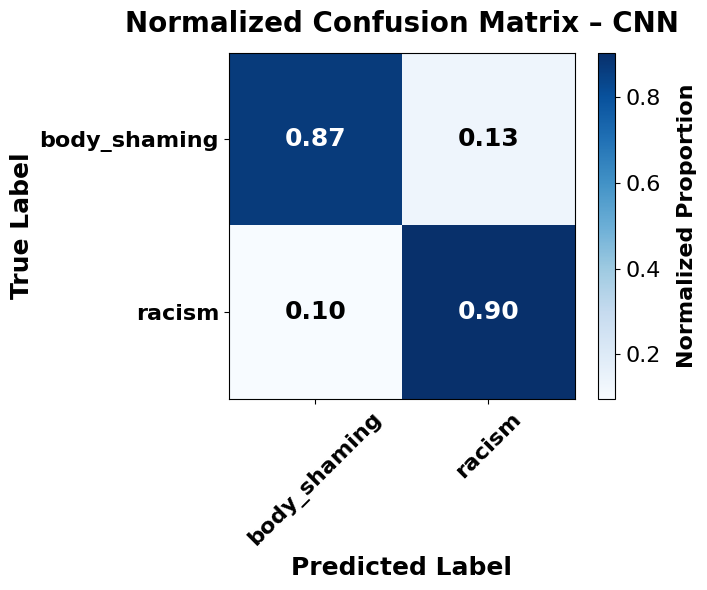

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import os

# -----------------------------
# Predictions (CNN) – FIXED
# -----------------------------
probs = model_cnn.predict(X_test_seq, batch_size=64).flatten()

# ✅ Use OPTIMAL threshold (not 0.5)
y_pred = (probs >= best_t).astype(int)

class_names = list(le.classes_)
print("Classes:", class_names)

# -----------------------------
# Confusion Matrix (RAW)
# -----------------------------
cm = confusion_matrix(y_test_seq, y_pred)
print("Raw Confusion Matrix:\n", cm)

# -----------------------------
# Normalized Confusion Matrix
# -----------------------------
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8, 6))
im = plt.imshow(cm_norm, interpolation='nearest', cmap=plt.cm.Blues)

plt.title(
    "Normalized Confusion Matrix – CNN",
    fontsize=20,
    fontweight='bold',
    pad=15
)

plt.xlabel("Predicted Label", fontsize=18, fontweight='bold')
plt.ylabel("True Label", fontsize=18, fontweight='bold')

# Axis ticks
plt.xticks(
    np.arange(len(class_names)),
    class_names,
    fontsize=16,
    fontweight='bold',
    rotation=45
)
plt.yticks(
    np.arange(len(class_names)),
    class_names,
    fontsize=16,
    fontweight='bold'
)

# Colorbar
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=16)
cbar.set_label(
    "Normalized Proportion",
    fontsize=16,
    fontweight='bold',
    labelpad=12
)

# -----------------------------
# Annotate Cells
# -----------------------------
fmt = ".2f"
thresh = cm_norm.max() / 2.0

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(
            j, i,
            format(cm_norm[i, j], fmt),
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold",
            color="white" if cm_norm[i, j] > thresh else "black"
        )

plt.tight_layout()

# -----------------------------
# Save
# -----------------------------
cm_path = os.path.join(PLOTS_DIR, "confusion_matrix_normalized_cnn_fixed.png")
plt.savefig(cm_path, dpi=500, bbox_inches="tight")
print("Saved:", cm_path)

plt.show()


Saved: /content/lstm_plots/loss_curve_cnn.png


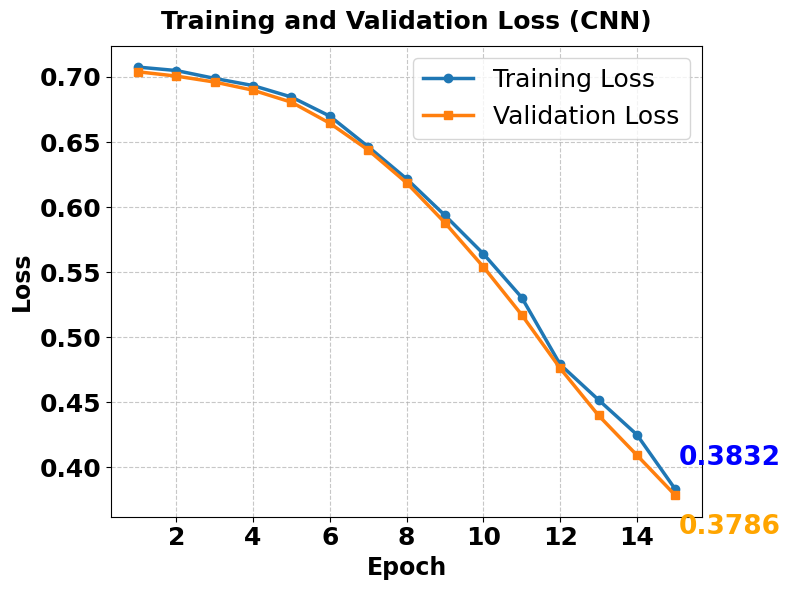

In [ ]:
import matplotlib.pyplot as plt
import os

# -----------------------------
# Loss Curve (CNN)
# -----------------------------
if 'history_cnn' in globals():

    plt.figure(figsize=(8, 6))
    epochs = range(1, len(history_cnn.history['loss']) + 1)

    # Training loss
    plt.plot(
        epochs,
        history_cnn.history['loss'],
        marker='o',
        linewidth=2.5,
        label='Training Loss'
    )

    # Validation loss
    if 'val_loss' in history_cnn.history:
        plt.plot(
            epochs,
            history_cnn.history['val_loss'],
            marker='s',
            linewidth=2.5,
            label='Validation Loss'
        )

    # Title & labels
    plt.title(
        "Training and Validation Loss (CNN)",
        fontsize=18,
        fontweight='bold',
        pad=12
    )
    plt.xlabel("Epoch", fontsize=17, fontweight='bold')
    plt.ylabel("Loss", fontsize=17, fontweight='bold')

    # Ticks
    plt.xticks(fontsize=18, fontweight='bold')
    plt.yticks(fontsize=18, fontweight='bold')

    # Grid
    plt.grid(True, linestyle='--', alpha=0.7)

  # -----------------------------
# Highlight final values (FIXED)
# -----------------------------
final_train_loss = history_cnn.history['loss'][-1]
final_val_loss = history_cnn.history['val_loss'][-1] if 'val_loss' in history_cnn.history else None

# Dynamic vertical offset
offset = 0.02 * max(history_cnn.history['loss'])

# Training loss annotation (slightly above)
plt.text(
    epochs[-1] + 0.1,
    final_train_loss + offset,
    f'{final_train_loss:.4f}',
    fontsize=19,
    fontweight='bold',
    color='blue',
    ha='left',
    va='bottom'
)

# Validation loss annotation (slightly below)
if final_val_loss is not None:
    plt.text(
        epochs[-1] + 0.1,
        final_val_loss - offset,
        f'{final_val_loss:.4f}',
        fontsize=19,
        fontweight='bold',
        color='orange',
        ha='left',
        va='top'
    )


    # Legend
    plt.legend(fontsize=18, loc='upper right', frameon=True)

    plt.tight_layout()

    # -----------------------------
    # Save figure
    # -----------------------------
    loss_path = os.path.join(PLOTS_DIR, "loss_curve_cnn.png")
    plt.savefig(loss_path, dpi=500, bbox_inches='tight')
    print("Saved:", loss_path)

    plt.show()


Saved: /content/lstm_plots/accuracy_curve_cnn.png


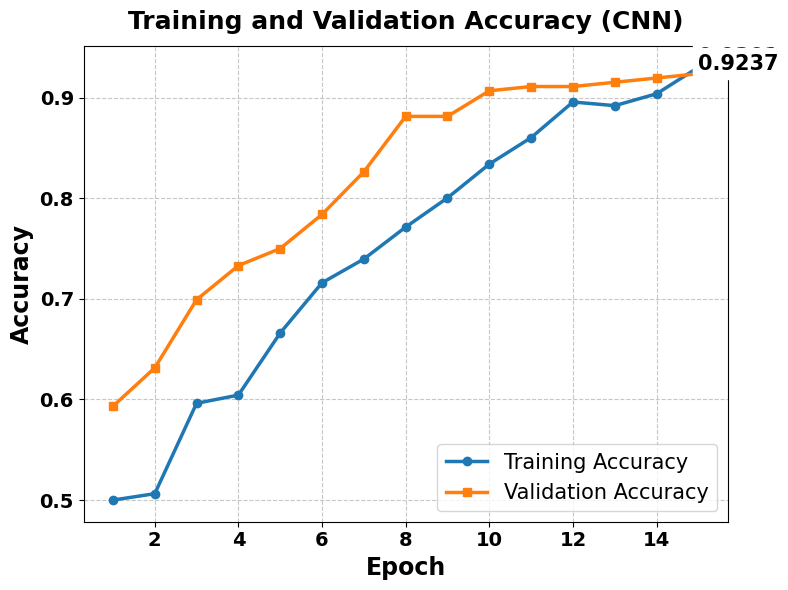

In [ ]:
import matplotlib.pyplot as plt
import os

# -----------------------------
# Accuracy Curve (CNN)
# -----------------------------
if 'history_cnn' in globals():

    plt.figure(figsize=(8, 6))
    epochs = range(1, len(history_cnn.history['accuracy']) + 1)

    # Training accuracy
    plt.plot(
        epochs,
        history_cnn.history['accuracy'],
        marker='o',
        linewidth=2.5,
        label='Training Accuracy'
    )

    # Validation accuracy
    if 'val_accuracy' in history_cnn.history:
        plt.plot(
            epochs,
            history_cnn.history['val_accuracy'],
            marker='s',
            linewidth=2.5,
            label='Validation Accuracy'
        )

    # Title & labels
    plt.title(
        "Training and Validation Accuracy (CNN)",
        fontsize=18,
        fontweight='bold',
        pad=12
    )
    plt.xlabel("Epoch", fontsize=17, fontweight='bold')
    plt.ylabel("Accuracy", fontsize=17, fontweight='bold')

    # Ticks
    plt.xticks(fontsize=14, fontweight='bold')
    plt.yticks(fontsize=14, fontweight='bold')

    # Grid
    plt.grid(True, linestyle='--', alpha=0.7)

    # -----------------------------
    # Highlight final values
    # -----------------------------
    final_train_acc = history_cnn.history['accuracy'][-1]
    plt.text(
        epochs[-1],
        final_train_acc,
        f'{final_train_acc:.4f}',
        fontsize=15,
        fontweight='bold',
        backgroundcolor='white',
        ha='left',
        va='bottom'
    )

    if 'val_accuracy' in history_cnn.history:
        final_val_acc = history_cnn.history['val_accuracy'][-1]
        plt.text(
            epochs[-1],
            final_val_acc,
            f'{final_val_acc:.4f}',
            fontsize=15,
            fontweight='bold',
            backgroundcolor='white',
            ha='left',
            va='bottom'
        )

    # Legend
    plt.legend(fontsize=15, loc='lower right', frameon=True)

    plt.tight_layout()

    # -----------------------------
    # Save figure
    # -----------------------------
    acc_path = os.path.join(PLOTS_DIR, "accuracy_curve_cnn.png")
    plt.savefig(acc_path, dpi=500, bbox_inches='tight')
    print("Saved:", acc_path)

    plt.show()


Saved: /content/lstm_plots/roc_curve_cnn.png


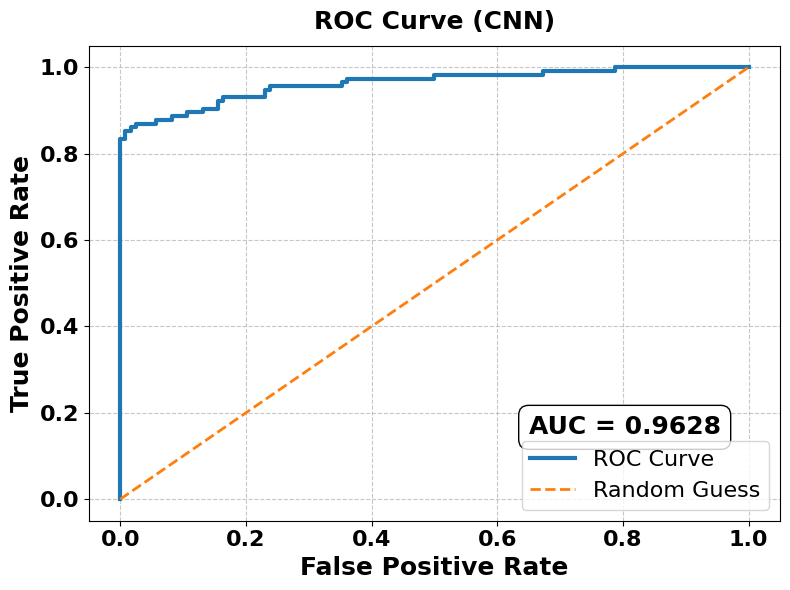

In [ ]:
import matplotlib.pyplot as plt
import os
from sklearn.metrics import roc_curve, auc

# -----------------------------
# ROC Curve (CNN)
# -----------------------------
fpr, tpr, _ = roc_curve(y_test_seq, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

# ROC curve
plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label='ROC Curve'
)

# Random baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=2,
    label='Random Guess'
)

# Title & labels
plt.title(
    "ROC Curve (CNN)",
    fontsize=18,
    fontweight='bold',
    pad=12
)
plt.xlabel("False Positive Rate", fontsize=18, fontweight='bold')
plt.ylabel("True Positive Rate", fontsize=18, fontweight='bold')

# Ticks
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')

# Grid
plt.grid(True, linestyle='--', alpha=0.7)

# -----------------------------
# AUC box (highlighted)
# -----------------------------
plt.text(
    0.65, 0.15,
    f"AUC = {roc_auc:.4f}",
    fontsize=18,
    fontweight='bold',
    bbox=dict(
        facecolor='white',
        edgecolor='black',
        boxstyle='round,pad=0.4'
    )
)

# Legend
plt.legend(fontsize=16, loc='lower right', frameon=True)

plt.tight_layout()

# -----------------------------
# Save figure
# -----------------------------
roc_path = os.path.join(PLOTS_DIR, "roc_curve_cnn.png")
plt.savefig(roc_path, dpi=500, bbox_inches='tight')
print("Saved:", roc_path)

plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd
import numpy as np
def get_model_metrics(name, model, X_test, y_test, label_encoder):
    preds = model.predict(X_test)

    if np.issubdtype(preds.dtype, np.floating):
        preds = (preds > 0.5).astype(int)
        if preds.ndim > 1:
            preds = preds.flatten()

    accuracy = accuracy_score(y_test, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, preds, average=None, labels=label_encoder.transform(label_encoder.classes_))

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(y_test, preds, average='macro')
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(y_test, preds, average='weighted')

    metrics = {
        'Model': name,
        'Accuracy': accuracy,
        'Precision (body_shaming)': precision[0],
        'Recall (body_shaming)': recall[0],
        'F1-Score (body_shaming)': f1[0],
        'Precision (racism)': precision[1],
        'Recall (racism)': recall[1],
        'F1-Score (racism)': f1[1],
        'Macro Avg Precision': macro_precision,
        'Macro Avg Recall': macro_recall,
        'Macro Avg F1-Score': macro_f1,
        'Weighted Avg Precision': weighted_precision,
        'Weighted Avg Recall': weighted_recall,
        'Weighted Avg F1-Score': weighted_f1,
    }
    return metrics

metrics_list = []

# Logistic Regression
metrics_list.append(get_model_metrics("Logistic Regression", lr, X_test_tfidf, y_test, le))

# SVM
metrics_list.append(get_model_metrics("SVM (Linear)", svc, X_test_tfidf, y_test, le))

# Random Forest
metrics_list.append(get_model_metrics("Random Forest", rf, X_test_tfidf, y_test, le))

metrics_list.append(get_model_metrics("BiLSTM", model_bilstm, X_test_seq, y_test_seq, le))


metrics_list.append(get_model_metrics("LSTM", model_lstm, X_test_seq, y_test_seq, le))

metrics_list.append(get_model_metrics("CNN", model_cnn, X_test_seq, y_test_seq, le))

# Create DataFrame and display
performance_df = pd.DataFrame(metrics_list)
display(performance_df.round(4))

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 357ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


,Model,Accuracy,Precision (body_shaming),Recall (body_shaming),F1-Score (body_shaming),Precision (racism),Recall (racism),F1-Score (racism),Macro Avg Precision,Macro Avg Recall,Macro Avg F1-Score,Weighted Avg Precision,Weighted Avg Recall,Weighted Avg F1-Score
0,Logistic Regression,0.9325,0.9274,0.9426,0.9350,0.9381,0.9217,0.9298,0.9327,0.9322,0.9324,0.9326,0.9325,0.9325
1,SVM (Linear),0.9536,0.9587,0.9508,0.9547,0.9483,0.9565,0.9524,0.9535,0.9537,0.9536,0.9536,0.9536,0.9536
2,Random Forest,0.9409,0.9355,0.9508,0.9431,0.9469,0.9304,0.9386,0.9412,0.9406,0.9408,0.9410,0.9409,0.9409
3,BiLSTM,0.9536,0.9302,0.9836,0.9562,0.9815,0.9217,0.9507,0.9559,0.9527,0.9534,0.9551,0.9536,0.9535
4,LSTM,0.5992,0.6134,0.5984,0.6058,0.5847,0.6000,0.5923,0.5991,0.5992,0.5990,0.5995,0.5992,0.5992
5,CNN,0.9198,0.8652,1.0000,0.9278,1.0000,0.8348,0.9100,0.9326,0.9174,0.9189,0.9306,0.9198,0.9191


In [ ]:
import pandas as pd
import numpy as np

def create_formatted_table(df_performance):
    models = df_performance['Model'].tolist()
    metrics_data = []

    def get_high_low(metric_name_low, metric_name_high, row):
        val_low = row[metric_name_low]
        val_high = row[metric_name_high]
        return (max(val_low, val_high), min(val_low, val_high)) if val_high > val_low else (min(val_low, val_high), max(val_low, val_high))

    metric_types = [
        ('Accuracy (%)', lambda r: r['Accuracy'] * 100, None, False),
        ('Precision', 'Precision (body_shaming)', 'Precision (racism)', True),
        ('Recall', 'Recall (body_shaming)', 'Recall (racism)', True),
        ('F1-Score', 'F1-Score (body_shaming)', 'F1-Score (racism)', True),
        ('Macro Avg F1', lambda r: r['Macro Avg F1-Score'], None, False),
        ('Weighted Avg F1', lambda r: r['Weighted Avg F1-Score'], None, False)
    ]

    for metric_label, metric_col_low, metric_col_high, is_high_low_metric in metric_types:
        if is_high_low_metric:
            high_values = [get_high_low(metric_col_low, metric_col_high, row)[0] for index, row in df_performance.iterrows()]
            low_values = [get_high_low(metric_col_low, metric_col_high, row)[1] for index, row in df_performance.iterrows()]
            metrics_data.append([f'{metric_label} (High)'] + high_values)
            metrics_data.append([f'{metric_label} (Low)'] + low_values)
        else:
            if callable(metric_col_low): # For Accuracy and Averages
                values = [metric_col_low(row) for index, row in df_performance.iterrows()]
            else:
                values = [row[metric_col_low] for index, row in df_performance.iterrows()]
            metrics_data.append([metric_label] + values)

    # Create DataFrame
    formatted_df = pd.DataFrame(metrics_data, columns=['Metric'] + models)

    return formatted_df.round(4)

formatted_table = create_formatted_table(performance_df)
display(formatted_table)


,Metric,Logistic Regression,SVM (Linear),Random Forest,BiLSTM,LSTM,CNN
0,Accuracy (%),93.2489,95.3586,94.0928,95.3586,59.9156,91.9831
1,Precision (High),0.9381,0.9483,0.9469,0.9815,0.5847,1.0000
2,Precision (Low),0.9274,0.9587,0.9355,0.9302,0.6134,0.8652
3,Recall (High),0.9217,0.9565,0.9304,0.9217,0.6000,0.8348
4,Recall (Low),0.9426,0.9508,0.9508,0.9836,0.5984,1.0000
5,F1-Score (High),0.9298,0.9524,0.9386,0.9507,0.5923,0.9100
6,F1-Score (Low),0.9350,0.9547,0.9431,0.9562,0.6058,0.9278
7,Macro Avg F1,0.9324,0.9536,0.9408,0.9534,0.5990,0.9189
8,Weighted Avg F1,0.9325,0.9536,0.9409,0.9535,0.5992,0.9191
